In [1]:
# SISO 5G gNB-UE Simulation using AIRSTRAN D 2200
import sys
import os

# Add src directory to Python path
sys.path.append(os.path.abspath('../src'))

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", message="invalid value encountered in multiply")
warnings.filterwarnings("ignore", category=UserWarning, module="jupyter_client")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, Transmitter, Receiver, Camera, PathSolver
from sionna.rt import AntennaArray, PlanarArray, SceneObject, ITURadioMaterial
from sionna.rt.antenna_pattern import antenna_pattern_registry

scene_xml_path = "../scene/scenes/Duke/scene.xml"
scene = load_scene(scene_xml_path)

2026-04-30 16:01:07 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [2]:
# ============================================
# SISO Configuration: gNB to UE
# ============================================

scene.frequency = 3.65e9  # 3.7 GHz

# Define UE position (fixed to start)
ue_position = [10.0, 0.0, 0.0]   # UE position (x, y, z in meters)

# ============================================
# Antenna Configuration
# ============================================

# gNB antenna: 3GPP TR 38.901 pattern (AIRSTRAN D 2200)
gnb_pattern_factory = antenna_pattern_registry.get("tr38901")
gnb_pattern = gnb_pattern_factory(polarization="V")

# Creating the pattern for the friendly jammer
friendly_jammer = antenna_pattern_registry.get("iso")
friendly_pattern = friendly_jammer(polarization="V")

# Rx pattern used to take measurements
ue_pattern_factory = antenna_pattern_registry.get("iso")
ue_pattern = ue_pattern_factory(polarization="V")

# SISO: Single antenna element at origin [0, 0, 0] for both TX and RX
single_element = np.array([[0.0, 0.0, 0.0]])  # Shape: (1, 3)

# Configure antenna arrays
scene.tx_array = AntennaArray(
    antenna_pattern=gnb_pattern,
    normalized_positions=single_element.T  # Shape: (3, 1)
)

jammer_array = AntennaArray(
    antenna_pattern=friendly_pattern,
    normalized_positions=single_element.T
)

scene.rx_array = AntennaArray(
    antenna_pattern=ue_pattern,
    normalized_positions=single_element.T  # Shape: (3, 1)
)

# ============================================
# Add Receiver to Scene
# ============================================

# Create UE receiver
rx = Receiver(name="ue", position=ue_position, display_radius=0.03)
scene.add(rx)

# ============================================
# Configure Propagation Environment
# ============================================

# Disable scattering for basic simulation
for radio_material in scene.radio_materials.values():
    radio_material.scattering_coefficient = 0.4

In [ ]:
from scene_parser import extract_building_info
from tx_placement import TxPlacement
# ============================================
# Place gNB on a Specific Building
# ============================================

#building_info = extract_building_info(scene_xml_path, verbose=True)
# Old: 37
#selected_building_id = 33  # Change this to your desired building number
# TxPlacement will create the transmitter if it doesn't exist and place it on the building
# Correct parameter order: (scene, tx_name, scene_xml_path, building_id, offset)
#tx_placer = TxPlacement(scene, "gnb", scene_xml_path, selected_building_id, offset=30.0)
#tx_placer.set_rooftop_center()
# Get reference to the transmitter (already added to scene by TxPlacement)
#tx = tx_placer.tx
# Convert to flat numpy array instead of nested list
#gnb_position = tx.position.numpy().flatten().tolist()
# Point antenna toward UE
#tx.look_at(ue_position)
#print(f"\nSuccess! gNB placed on building {selected_building_id}")
#print(f"Position: {gnb_position}")

# Adding a transmitter (unconstrained)
gnb_position = [75.0, 75.0, 35.0]
tx = Transmitter(name="tx", position=gnb_position)
scene.add(tx)

# ============================================
# Compute Propagation Paths
# ============================================

# Instantiate path solver
p_solver = PathSolver()

# Compute propagation paths
paths = p_solver(
    scene=scene,
    max_depth=5,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=False,
    seed=41
)

# ============================================
# Visualize Scene
# ============================================

# Setup camera
cam = Camera(position=(100.0, 100.0, 50.0))
cam.look_at(gnb_position)

# Preview the scene with propagation paths
#scene.preview(
#    paths=paths,
#    resolution=[1000, 1000],
#    clip_at=200,
#    show_orientations=True
#)

In [4]:
from boresight_pathsolver import create_zone_mask
import numpy as np

map_config = {
    'center': [0.0, 0.0, 0.0],
    'size': [1400, 1400],
    'cell_size': (0.5, 0.5),
    'ground_height': 0.0,
}

extent = [
    map_config['center'][0] - map_config['size'][0] / 2,
    map_config['center'][0] + map_config['size'][0] / 2,
    map_config['center'][1] - map_config['size'][1] / 2,
    map_config['center'][1] + map_config['size'][1] / 2,
]

zone_params = {
    'center': [0.0, 0.0],
    'width': 250,
    'height': 250,
}

zone_mask, naive_look_at, zone_stats = create_zone_mask(
    map_config=map_config,
    zone_type='box',
    origin_point=gnb_position,
    zone_params=zone_params,
    target_height=0.0,
    scene_xml_path=scene_xml_path,
    exclude_buildings=True,
)
print(f"Zone contains {zone_stats['num_cells']} grid cells")
print(f"Zone coverage: {zone_stats['coverage_fraction']*100:.1f}% of map")
print(f"Naive baseline look-at: {zone_stats['look_at_xyz']}")
print(f"Zone centroid: {zone_stats['centroid_xy']}")

Zone contains 166571 grid cells
Zone coverage: 2.1% of map
Naive baseline look-at: [0.0, 0.0, 0.0]
Zone centroid: [-2.0123205720083326, -6.857695817399187]


In [5]:
from tx_placement import TxPlacement

#selected_building_id_2 = 21
#tx_placer2 = TxPlacement(scene, 'gnb2', scene_xml_path,
#                          selected_building_id_2, offset=30.0)
#tx_placer2.set_rooftop_center()
#tx2 = tx_placer2.tx
#tx2.look_at([0.0, 600.0, 0.0])

gnb2_position = [-50.0, -50.0, 45.0]
tx2 = Transmitter(name="tx2", position=gnb2_position)
scene.add(tx2)

#gnb2_position = tx2.position.numpy().flatten().tolist()
#print(f'gnb2 placed on building {selected_building_id_2}')
#print(f'Position: {gnb2_position}')

In [6]:
from boresight_pathsolver import create_zone_mask

zone_params2 = {
    'center': [0.0, 100.00],
    'width': 250,
    'height': 250,
}

zone_mask2, naive_look_at2, zone_stats2 = create_zone_mask(
    map_config=map_config,
    zone_type='box',
    origin_point=gnb2_position,
    zone_params=zone_params2,
    target_height=0.0,
    scene_xml_path=scene_xml_path,
    exclude_buildings=True,
)
print(f"Zone 2 contains {zone_stats2['num_cells']} grid cells")
print(f"Zone coverage: {zone_stats2['coverage_fraction']*100:.1f}% of map")
print(f"Naive baseline look-at: {zone_stats2['look_at_xyz']}")
print(f"Zone centroid: {zone_stats2['centroid_xy']}")

Zone 2 contains 150654 grid cells
Zone coverage: 1.9% of map
Naive baseline look-at: [0.0, 100.0, 0.0]
Zone centroid: [-2.432195627065992, 108.57939716170829]


import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
import numpy as np

zone_list = [
    (zone_mask,  zone_stats,  gnb_position,  'gnb',  selected_building_id,   'Greens', 'darkgreen'),
    (zone_mask2, zone_stats2, gnb2_position, 'gnb2', selected_building_id_2, 'Blues',  'steelblue'),
]

_extent = [
    map_config['center'][0] - map_config['size'][0] / 2,
    map_config['center'][0] + map_config['size'][0] / 2,
    map_config['center'][1] - map_config['size'][1] / 2,
    map_config['center'][1] + map_config['size'][1] / 2,
]

fig, ax = plt.subplots(figsize=(10, 8))

for mask, stats, tx_pos, name, bldg_id, cmap, color in zone_list:
    ax.imshow(np.ma.masked_where(mask == 0, mask),
              origin='lower', cmap=cmap, extent=_extent, vmin=0, vmax=1, alpha=0.5)
    ax.plot(tx_pos[0], tx_pos[1], '*', color=color,
            markersize=20, markeredgecolor='black', label=f'{name} TX (bldg {bldg_id})')
    ax.plot(stats['centroid_xy'][0], stats['centroid_xy'][1], 'o', color=color,
            markersize=10, markeredgecolor='black', label=f'{name} centroid')
    ax.plot(stats['look_at_xyz'][0], stats['look_at_xyz'][1], '^', color=color,
            markersize=10, markeredgecolor='black', label=f'{name} naive baseline')

for building_id, bldg_data in building_info.items():
    verts = bldg_data['vertices'][:, :2]
    ax.add_patch(MPLPolygon(verts, closed=True, facecolor='gray',
                            edgecolor='black', linewidth=1.5, alpha=0.3))
    ax.text(np.mean(verts[:, 0]), np.mean(verts[:, 1]), str(building_id),
            fontsize=6, ha='center', va='center', color='black', alpha=0.7)

ax.set_title(f'Coverage Zone Masks — {len(zone_list)} transmitters')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [7]:
from multi_tx_optimizer import TxConfig

# Build TxConfig list — order must match scene insertion order
tx_configs = [
    TxConfig(
        name='tx',
        on_building=False,
        building_id=1,
        zone_params=zone_params,
    ),
    TxConfig(
        name='tx2',
        on_building=False,
        building_id=2,
        zone_params=zone_params,
    ),
]

-700.0

MULTI-TX SIR OPTIMIZATION  (2 transmitters)
Tx Position: [50.0, 50.0, 35.0]
look_at_position: [0.0, 0.0, 1.5]
Tx Position: [-50.0, -50.0, 45.0]
look_at_position: [0.0, 0.0, 1.5]
2026-04-30 16:01:13 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Pre-created 101 shared receivers across 2 base stations


jit_flush_malloc_cache(): Dr.Jit exhausted the available memory and had to flush its allocation cache to free up additional memory. This is an expensive operation and will have a negative effect on performance. You may want to change your computation so that it uses less memory. This warning will only be displayed once.


  [dbg] mean gNB power  : 1.31392e-09
  [dbg] mean jam power  : 1.39854e-08
  [dbg] mean best-SINR  : 6.03459


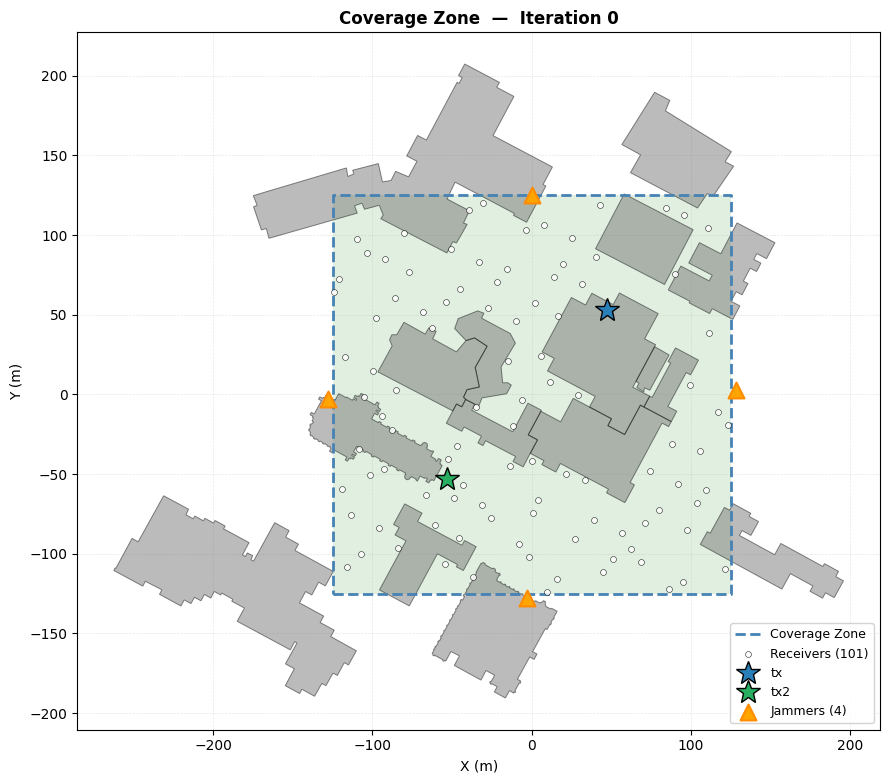

  Iter   1/25  loss=1.2688  (3.0s)
  [dbg] mean gNB power  : 2.13459e-09
  [dbg] mean jam power  : 2.59976e-09
  [dbg] mean best-SINR  : 17.8221


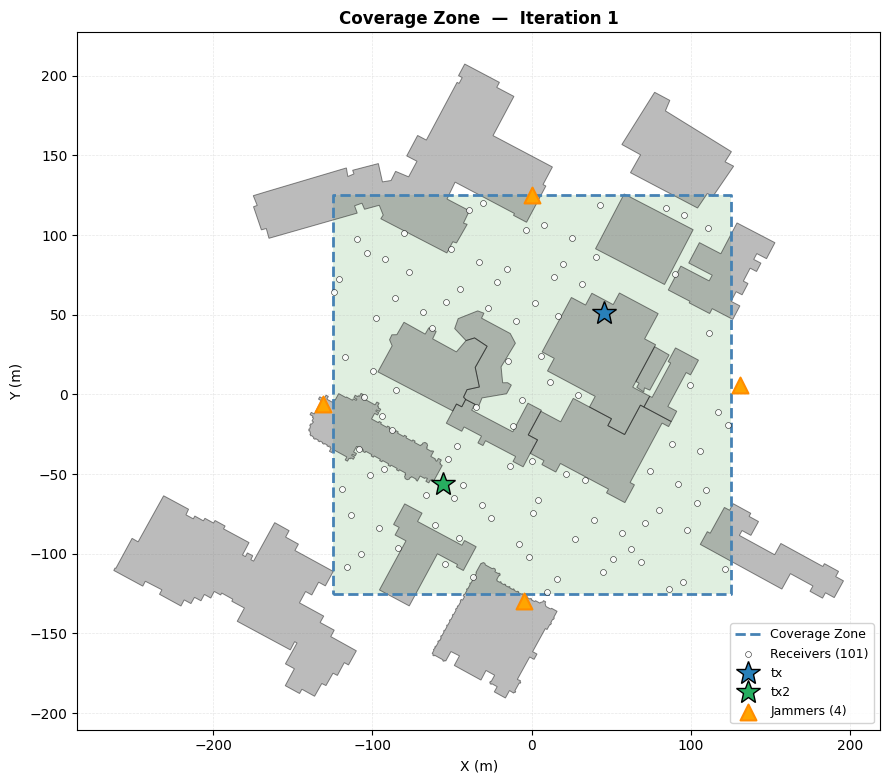

  Iter   2/25  loss=-0.2168  (3.4s)
  [dbg] mean gNB power  : 2.21282e-09
  [dbg] mean jam power  : 7.8445e-10
  [dbg] mean best-SINR  : 18.0094


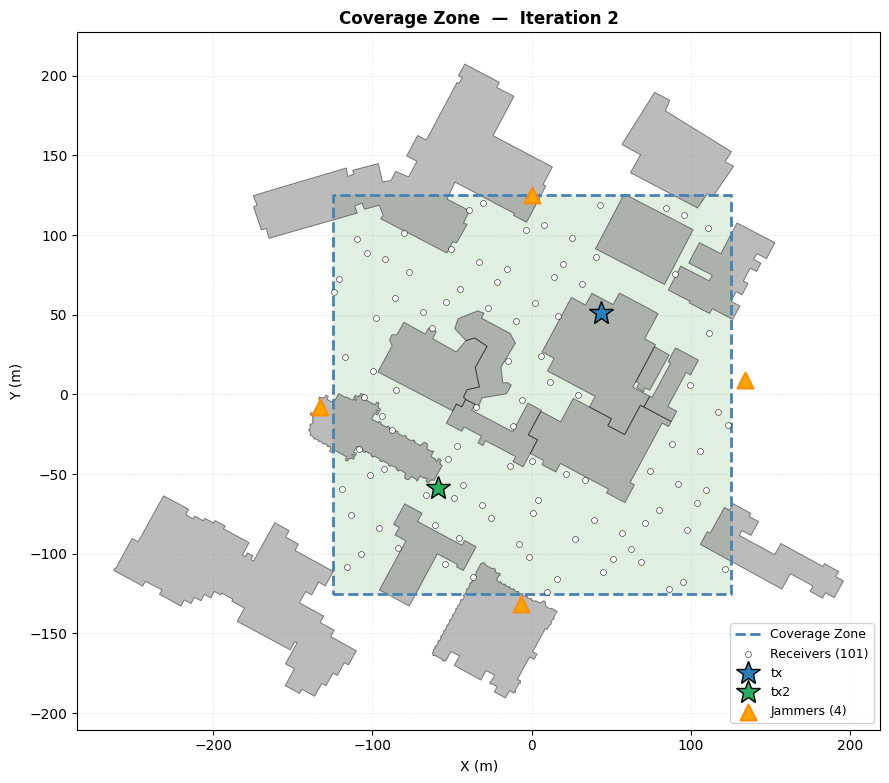

  Iter   3/25  loss=-0.7939  (3.6s)
  [dbg] mean gNB power  : 2.41884e-09
  [dbg] mean jam power  : 3.37551e-10
  [dbg] mean best-SINR  : 24.7464


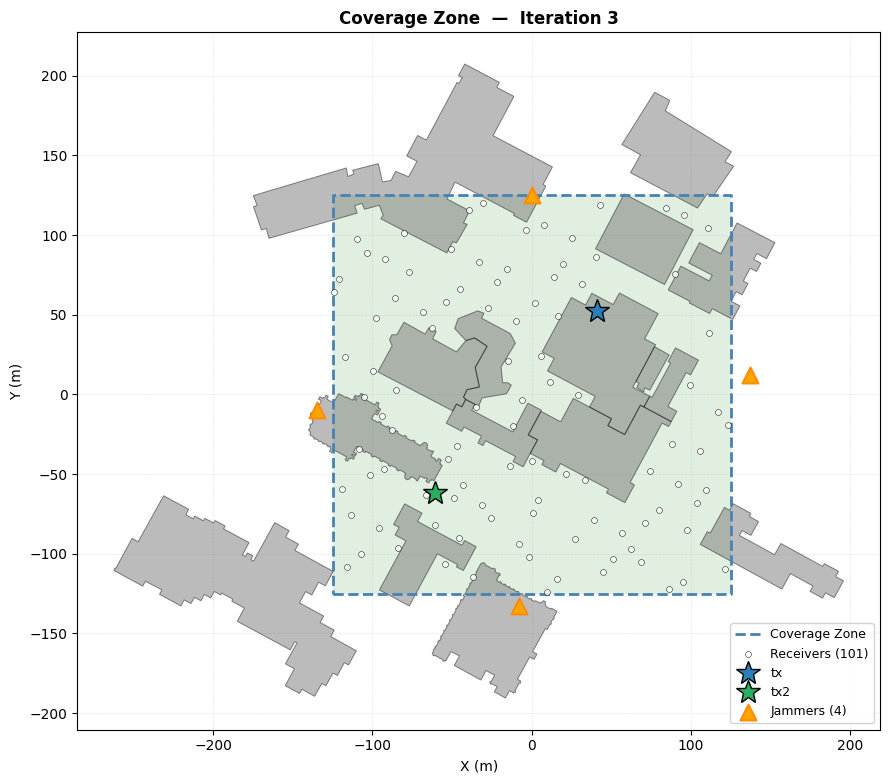

  Iter   4/25  loss=-1.1263  (3.4s)
  [dbg] mean gNB power  : 2.68606e-09
  [dbg] mean jam power  : 1.47747e-10
  [dbg] mean best-SINR  : 30.3583


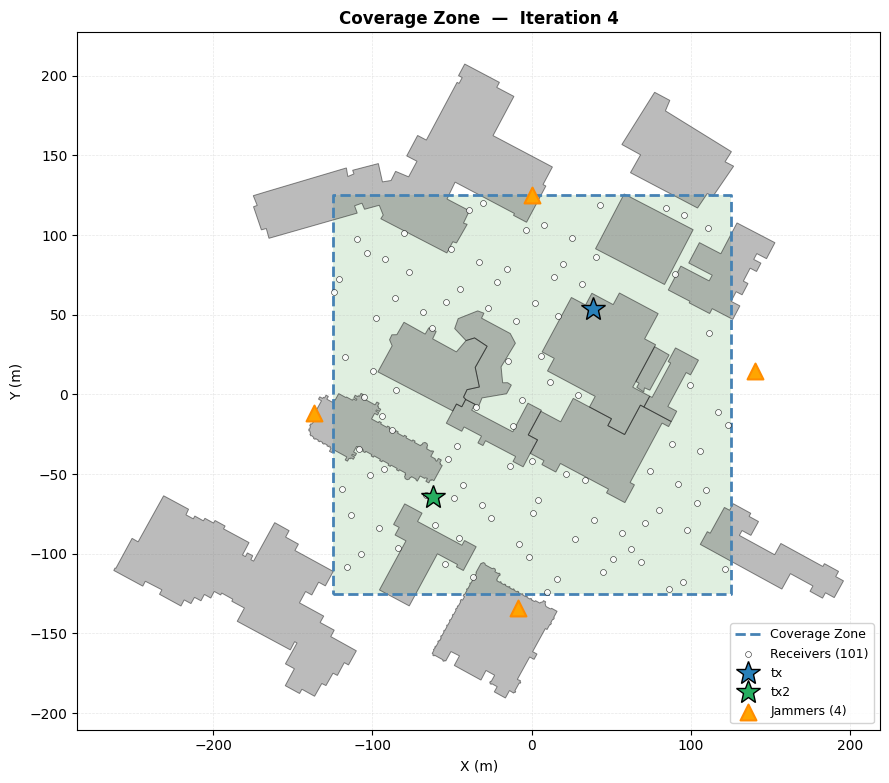

  Iter   5/25  loss=-1.5463  (3.6s)
  [dbg] mean gNB power  : 3.5299e-09
  [dbg] mean jam power  : 8.5673e-11
  [dbg] mean best-SINR  : 31.4878


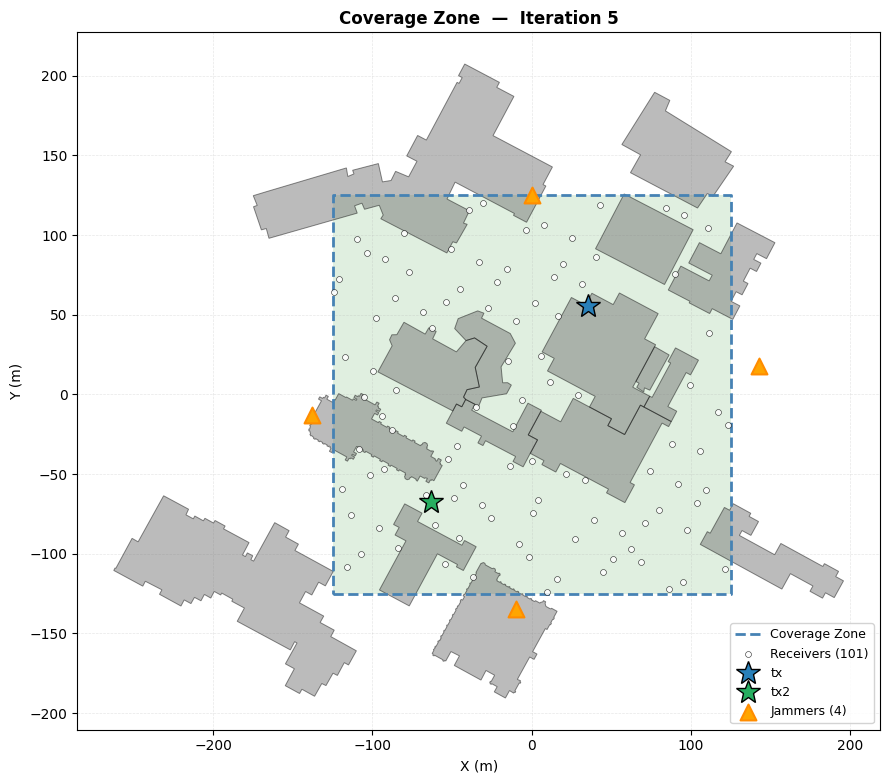

  Iter   6/25  loss=-1.6004  (3.1s)


RuntimeError: dr.while_loop(): encountered an exception (see above).

In [ ]:
from multi_tx_optimizer import optimize_multi_tx, JammerConfig

from boresight_pathsolver import visualize_multi_tx_strata
import matplotlib.pyplot as plt

def strata_callback(iteration, tx_states, tx_configs, jam_positions=None):
    fig = visualize_multi_tx_strata(
        tx_states, tx_configs, map_config, iteration=iteration,
        jam_positions=jam_positions,
    )
    plt.show()
    plt.close(fig)

jam_configs = [
    JammerConfig(name="jam_0", initial_power_dbm=23.0, initial_position=[0.0, 125.0]),
    JammerConfig(name="jam_1", initial_power_dbm=23.0, initial_position=[-125.0, 0.0]),
    JammerConfig(name="jam_2", initial_power_dbm=23.0, initial_position=[0.0, -125.0]),
    JammerConfig(name="jam_3", initial_power_dbm=23.0, initial_position=[125.0, 0.0])
]

multi_result = optimize_multi_tx(
    scene=scene,
    tx_configs=tx_configs,
    map_config=map_config,
    scene_xml_path=scene_xml_path,
    jammer_array=jammer_array,
    jam_configs=jam_configs,
    num_sample_points=100,
    learning_rate=3.0,
    num_iterations=25,
    noise_power=1e-10,
    dead_tail_percentile=60.0,
    max_dbscan_points=100_000,
    lds='Halton',
    sampler='rejection',
    debug_viz=False,
    sampling_strata='full',
    on_iteration_callback=strata_callback,
)

for tx_name, res in multi_result.items():
    if tx_name == 'joint':
        print(f'Final SIR loss: {res["loss_history"][-1]:.4f}')
        print(f'Elapsed: {res["elapsed_time_s"]:.1f}s')
    else:
        print(f'{tx_name}: Az={res["best_angles"][0]:.1f}°, '
              f'El={res["best_angles"][1]:.1f}°')
        print(f'  Position: ({res["final_position"][0]:.2f}, '
              f'{res["final_position"][1]:.2f})')

In [ ]:
from multi_tx_optimizer import compare_multi_tx_performance
import matplotlib.pyplot as plt
import json

zone_masks_dict = {
    'gnb':  zone_mask,
    'gnb2': zone_mask2,
}

fig_cmp, comparison_stats = compare_multi_tx_performance(
    scene=scene,
    tx_configs=tx_configs,
    multi_result=multi_result,
    map_config=map_config,
    zone_masks=zone_masks_dict,
    noise_power=1e-10,
)
plt.show()

# Print summary
for tx_name, s in comparison_stats.items():
    if tx_name == 'joint':
        continue
    imp = s['improvement']
    print(f'\n{tx_name} improvement:')
    print(f'  RSRP mean: {imp["rsrp_mean_db"]:+.2f} dB')
    print(f'  RSRP p10:  {imp["rsrp_p10_db"]:+.2f} dB')
    print(f'  SIR median:{imp["sir_median_db"]:+.2f} dB')
    print(f'  SIR p10:   {imp["sir_p10_db"]:+.2f} dB')

# Save serialisable stats for offline analysis
save_stats = {k: v for k, v in comparison_stats.items()}
# Strip large value arrays to keep JSON compact (comment out to keep full arrays)
for tx_name, s in save_stats.items():
    if tx_name == 'joint':
        continue
    for cfg_key in ('initial', 'optimized'):
        s[cfg_key].pop('rsrp_values_dbm', None)
        s[cfg_key].pop('sir_values_db', None)

with open('multi_tx_comparison.json', 'w') as f:
    json.dump(save_stats, f, indent=2)
print('\nStats saved to multi_tx_comparison.json')


In [ ]:
# Visualizing TX placement and orientation before and after optimization
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon

tx_entries = [
    ('gnb',  selected_building_id),
    ('gnb2', selected_building_id_2),
]

arrow_scale = 20.0  # length of the boresight direction arrow (metres)

fig, axes = plt.subplots(1, len(tx_entries), figsize=(7 * len(tx_entries), 6))
if len(tx_entries) == 1:
    axes = [axes]

for ax, (tx_name, bldg_id) in zip(axes, tx_entries):
    r = multi_result[tx_name]

    init_pos  = r['initial_position']   # [x, y, z]
    opt_pos   = r['final_position']     # [x, y, z]
    init_az   = np.radians(r['initial_angles'][0])
    opt_az    = np.radians(r['best_angles'][0])

    # Building polygon
    poly_verts = building_info[bldg_id]['vertices']
    poly = Polygon(poly_verts)
    plot_polygon(poly, ax=ax, facecolor='lightgray', edgecolor='black', add_points=False)

    # Positions
    ax.plot(init_pos[0], init_pos[1], 'rx',
            markersize=12, markeredgewidth=2, label='Initial TX')
    ax.plot(opt_pos[0],  opt_pos[1],  'bo',
            markersize=10, markeredgewidth=2, label='Optimized TX')

    # Boresight direction arrows (azimuth projected onto XY plane)
    ax.annotate('', xy=(init_pos[0] + arrow_scale * np.cos(init_az),
                        init_pos[1] + arrow_scale * np.sin(init_az)),
                xytext=(init_pos[0], init_pos[1]),
                arrowprops=dict(arrowstyle='->', color='red',
                                lw=2, linestyle='dashed'))

    ax.annotate('', xy=(opt_pos[0] + arrow_scale * np.cos(opt_az),
                        opt_pos[1] + arrow_scale * np.sin(opt_az)),
                xytext=(opt_pos[0], opt_pos[1]),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

    # Invisible proxy artists for the orientation arrows in the legend
    from matplotlib.lines import Line2D
    proxy_init = Line2D([0], [0], color='red',  lw=2, linestyle='dashed',
                        label=f'Initial Az: {r["initial_angles"][0]:.1f}°')
    proxy_opt  = Line2D([0], [0], color='blue', lw=2,
                        label=f'Optimized Az: {r["best_angles"][0]:.1f}°')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [proxy_init, proxy_opt])

    ax.set_title(f'{tx_name} Placement on Building {bldg_id}')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

    # Expand axis limits to ensure both arrow tips are visible
    arrow_tips_x = [init_pos[0] + arrow_scale * np.cos(init_az),
                    opt_pos[0]  + arrow_scale * np.cos(opt_az)]
    arrow_tips_y = [init_pos[1] + arrow_scale * np.sin(init_az),
                    opt_pos[1]  + arrow_scale * np.sin(opt_az)]
    pad = arrow_scale
    cur_xl, cur_xr = ax.get_xlim()
    cur_yb, cur_yt = ax.get_ylim()
    ax.set_xlim(min(cur_xl, min(arrow_tips_x) - pad), max(cur_xr, max(arrow_tips_x) + pad))
    ax.set_ylim(min(cur_yb, min(arrow_tips_y) - pad), max(cur_yt, max(arrow_tips_y) + pad))

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()